# Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Load Dataset

In [3]:
df = pd.read_csv("wine.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4



# Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [6]:
df.shape

(1143, 13)

# Check Missing Values

In [6]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

# Check Duplicate Values

In [7]:
df.duplicated().sum()

np.int64(0)

# Drop ID Column

In [8]:
df.drop("Id", axis=1, inplace=True)

# Data Visualization

# Correlation Heatmap

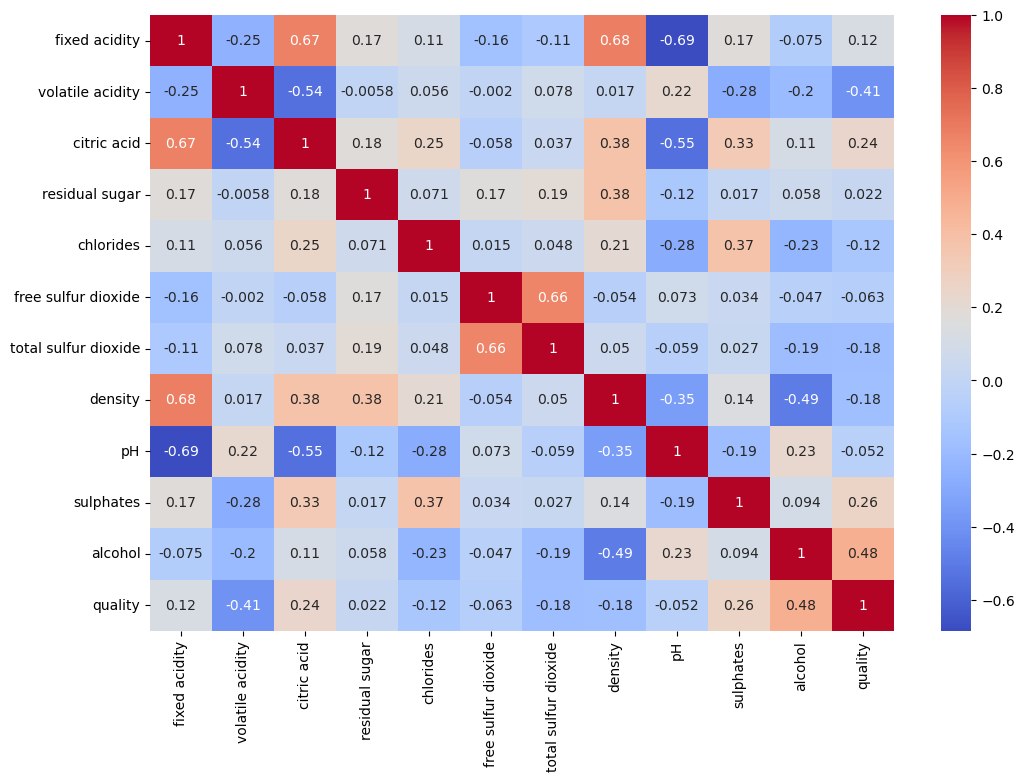

In [9]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.show()

# Wine Quality Distribution

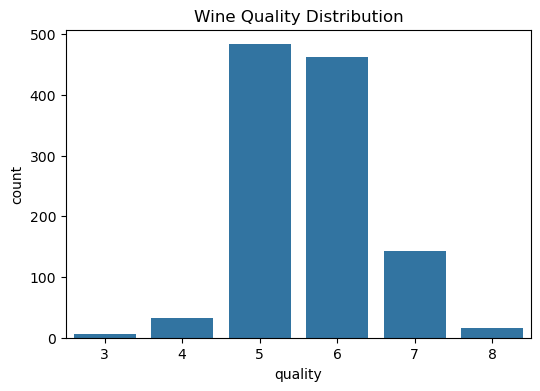

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x="quality", data=df)

plt.title("Wine Quality Distribution")

plt.show()

# Alcohol Distribution

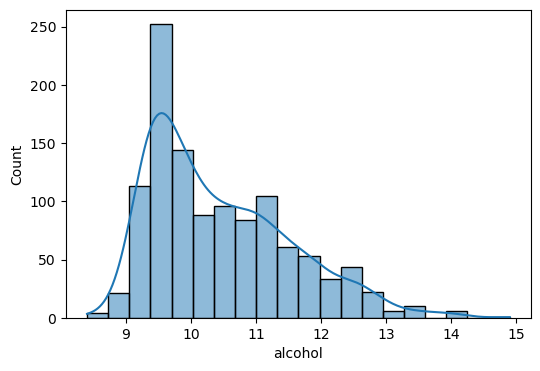

In [11]:
plt.figure(figsize=(6,4))

sns.histplot(df["alcohol"], bins=20, kde=True)

plt.show()

# Density Distribution

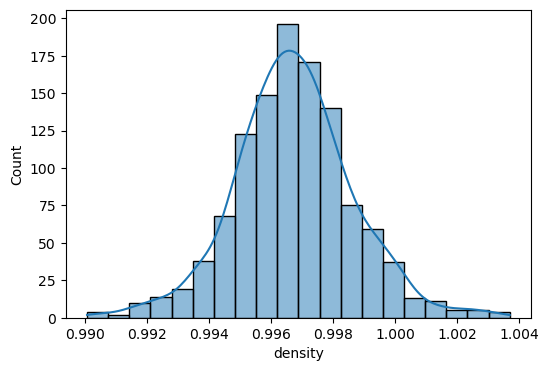

In [12]:
plt.figure(figsize=(6,4))

sns.histplot(df["density"], bins=20, kde=True)

plt.show()

# Boxplot

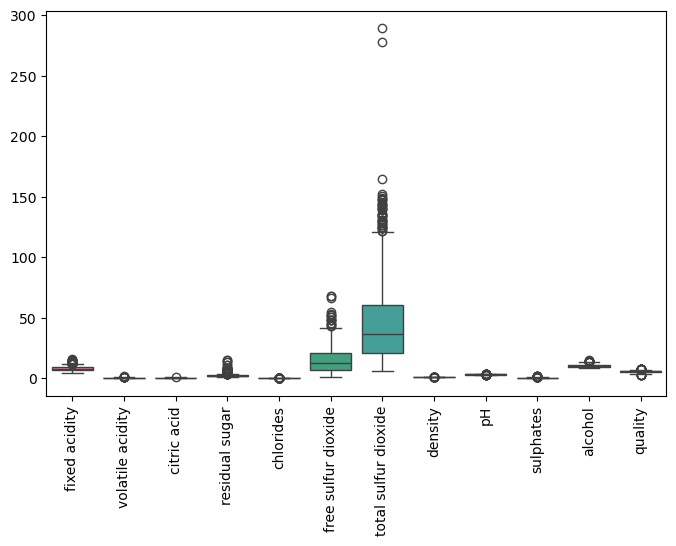

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

# Convert Quality into Binary Classes

In [14]:
df["quality"] = df["quality"].apply(lambda x: 1 if x >= 7 else 0)

df["quality"].value_counts()

quality
0    984
1    159
Name: count, dtype: int64

# Separate Features and Target

In [15]:
X = df.drop("quality", axis=1)

y = df["quality"]

# Split Dataset

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Random Forest Classifier

In [19]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:")

print(accuracy_score(y_test, rf_pred))

Random Forest Accuracy:
0.9170305676855895


In [20]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       201
           1       0.70      0.57      0.63        28

    accuracy                           0.92       229
   macro avg       0.82      0.77      0.79       229
weighted avg       0.91      0.92      0.91       229



In [21]:
print(confusion_matrix(y_test, rf_pred))

[[194   7]
 [ 12  16]]


# SGD Classifier

In [22]:
sgd = SGDClassifier(random_state=42)

sgd.fit(X_train, y_train)

sgd_pred = sgd.predict(X_test)

print("SGD Accuracy:")

print(accuracy_score(y_test, sgd_pred))

SGD Accuracy:
0.868995633187773


In [23]:
print(classification_report(y_test, sgd_pred))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92       201
           1       0.47      0.57      0.52        28

    accuracy                           0.87       229
   macro avg       0.70      0.74      0.72       229
weighted avg       0.88      0.87      0.87       229



# Support Vector Classifier (SVC)


In [24]:
svc = SVC(random_state=42)

svc.fit(X_train, y_train)

svc_pred = svc.predict(X_test)

print("SVC Accuracy:")

print(accuracy_score(y_test, svc_pred))

SVC Accuracy:
0.8908296943231441


In [25]:
print(classification_report(y_test, svc_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       201
           1       0.62      0.29      0.39        28

    accuracy                           0.89       229
   macro avg       0.76      0.63      0.67       229
weighted avg       0.87      0.89      0.87       229



# Compare Model Accuracy

In [26]:
accuracy = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD",
        "Support Vector"
    ],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ]
})

accuracy

,Model,Accuracy
0,Random Forest,0.917031
1,SGD,0.868996
2,Support Vector,0.890830


# Accuracy Bar Chart

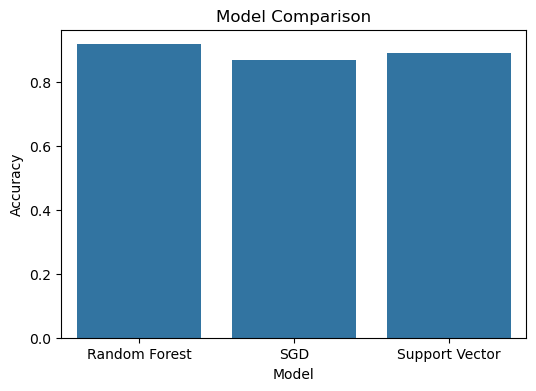

In [27]:
plt.figure(figsize=(6,4))

sns.barplot(data=accuracy, x="Model", y="Accuracy")

plt.title("Model Comparison")

plt.show()